# GCI and GI Efficiency Comparison for All Control Strategies


In [1]:
import math
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import TwoSlopeNorm
from joblib import Parallel, delayed

from SWMM import SWMM_ENV as SWMM_ENV
from DQN import DQN as DQN
from HC import HC as HC

from pyswmm import Simulation, Links, Nodes, RainGages, SystemStats
from swmm_api.input_file import read_inp_file
from swmm_api.input_file.sections.others import TimeseriesData
from swmm_api.input_file.sections import Control
from swmm_api.input_file.section_labels import TIMESERIES, CONTROLS

import yaml

config = {
    "font.family": "serif",
    "font.size": 12,
    "mathtext.fontset": "stix",
    "font.serif": ["Times New Roman"],
    "axes.unicode_minus": False,
}
rcParams.update(config)


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path(".")
RAIN_START = 50
NUM_RAINFALLS = 30
RAIN_IDS = list(range(RAIN_START, RAIN_START + NUM_RAINFALLS))
ONE_STEP_MINUTES = 5

NO_GI_RESULTS_DIR = ROOT / "results_gci_gi_efficiency_noGI"
FIGURE_DIR = ROOT / "figures_gci_gi_efficiency_integral_fc"
TABLE_DIR = FIGURE_DIR / "tables"

NO_GI_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Simulation switches
RUN_HC_NO_GI = False
RUN_DQN_NO_GI = False
RUN_MPC_NO_GI = False

HC_NO_GI_PATH = NO_GI_RESULTS_DIR / "HC_noGI.npy"
DRL_BASE_NO_GI_PATH = NO_GI_RESULTS_DIR / "DQN3_base_noGI.npy"
DRL_GIENV_NO_GI_PATH = NO_GI_RESULTS_DIR / "DQN3_gienv_noGI.npy"
DRL_GCI_NO_GI_PATH = NO_GI_RESULTS_DIR / "DQN3_gci_noGI.npy"
MPC_NO_GI_PATH = NO_GI_RESULTS_DIR / "MPC_noGI.npy"

MPC_TEMP_ROOT = ROOT / "SWMM" / "_temopt_gi_efficiency"
MPC_WARM_START_PATH = DRL_BASE_NO_GI_PATH
MPC_WARM_START_ENV_KEY = "env4"

MPC_POP_PARAM = {
    "pop_size": 10,
    "max_value": 127,
    "optstep": 150,
    "simulation_steps": 95,
}

STRATEGY_ORDER = ["HC", "MPC", "DRL-Base", "DRL-GIenv", "DRL-GCI"]
STRATEGY_COLORS = {
    "HC": "#6baed6",
    "MPC": "#41b6c4",
    "DRL-Base": "#a1d99b",
    "DRL-GIenv": "#31a354",
    "DRL-GCI": "#006837",
}
STRATEGY_MARKERS = {
    "HC": "^",
    "MPC": "D",
    "DRL-Base": "o",
    "DRL-GIenv": "P",
    "DRL-GCI": "*",
}


In [3]:
def load_record(path):
    path = Path(path)
    return np.load(path, allow_pickle=True).tolist()


def read_nested(data, path):
    current = data
    for key in path:
        current = current[key]
    return current


def series_flooding_cso(record, rainfall_key, flooding_path, cso_path, skip=2):
    flooding = np.asarray(read_nested(record[rainfall_key], flooding_path), dtype=float)[skip:] / 1000.0
    cso = np.asarray(read_nested(record[rainfall_key], cso_path), dtype=float)[skip:] / 1000.0
    return flooding + cso


def final_flooding_cso(record, rainfall_key, flooding_path, cso_path, skip=2):
    series = series_flooding_cso(record, rainfall_key, flooding_path, cso_path, skip=skip)
    return float(series[-1])


def integrated_flooding_cso(record, rainfall_key, flooding_path, cso_path, skip=2):
    series = series_flooding_cso(record, rainfall_key, flooding_path, cso_path, skip=skip)
    return float(np.sum(series))


def inflow_series(record, rainfall_key, inflow_path, skip=2):
    return np.asarray(read_nested(record[rainfall_key], inflow_path), dtype=float)[skip:] / 1000.0


def delta1_from_baseline_and_gi(base_record, gi_record, rainfall_key):
    base_in = inflow_series(base_record, rainfall_key, ["env4", "inflow"])
    gi_in = inflow_series(gi_record, rainfall_key, ["env3", "inflow"])
    min_length = min(len(base_in), len(gi_in))
    return float(np.sum(base_in[:min_length] - gi_in[:min_length]))


def safe_divide(num, den):
    if den == 0:
        return np.nan
    return num / den


def ensure_paths_exist(paths):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))


def rainfall_display_id(rain_id):
    return rain_id - RAIN_START + 1


def build_metric_tables(metric_df, value_col):
    overall = (
        metric_df.groupby("strategy")[value_col]
        .agg(["mean", "std", "var", "min", "max", "count"])
        .reset_index()
    )
    event_level = metric_df[["rainfall_id", "rainfall_display", "strategy", value_col]].copy()
    return overall, event_level


In [4]:
raindata = np.load(ROOT / "rainfall" / "training_raindata.npy", allow_pickle=True).tolist()

r_base = load_record(ROOT / "results" / "HC.npy")
r_gi_only = load_record(ROOT / "results" / "HC_GI.npy")

existing_gi_specs = {
    "HC": {
        "record": load_record(ROOT / "results" / "HC_GI_true.npy"),
        "flooding_path": ["env5", "flooding"],
        "cso_path": ["env5", "CSO"],
    },
    "MPC": {
        "record": load_record(ROOT / "results" / "MPC_GI.npy"),
        "flooding_path": ["flooding"],
        "cso_path": ["CSO"],
    },
    "DRL-Base": {
        "record": load_record(ROOT / "results" / "DQN3_GI.npy"),
        "flooding_path": ["env3", "flooding"],
        "cso_path": ["env3", "CSO"],
    },
    "DRL-GIenv": {
        "record": load_record(ROOT / "results" / "DQN3_train_GI.npy"),
        "flooding_path": ["env3", "flooding"],
        "cso_path": ["env3", "CSO"],
    },
    "DRL-GCI": {
        "record": load_record(ROOT / "results" / "DQN3_GI_new.npy"),
        "flooding_path": ["env_new", "flooding"],
        "cso_path": ["env_new", "CSO"],
    },
}

print("Loaded existing GI-side records for:", list(existing_gi_specs.keys()))
print("Design rainfall IDs:", RAIN_IDS[0], "...", RAIN_IDS[-1])


Loaded existing GI-side records for: ['HC', 'MPC', 'DRL-Base', 'DRL-GIenv', 'DRL-GCI']
Design rainfall IDs: 50 ... 79


## No-GI HC and DQN Simulations

Not executed by default. Set `RUN_HC_NO_GI` or `RUN_DQN_NO_GI` to `True` when needed.


In [5]:
env_params_hc_no_gi = {
    "orf": "SWMM/chaohu",
    "orf_save": "chaohu_RTC",
    "parm": "states_yaml/chaohu",
    "advance_seconds": 300,
    "kf": 1,
    "kc": 1,
    "reward_type": "3",
}

env_params_no_gi = {
    "orf": "SWMM/chaohu_noHC",
    "orf_save": "chaohu_RTC",
    "parm": "states_yaml/chaohu",
    "advance_seconds": 300,
    "kf": 1,
    "kc": 1,
    "reward_type": "3",
}


def hc_interact(rain_id, env, rainfall_series):
    observation = env.reset(rainfall_series[rain_id], rain_id, False, ".")
    storage_states = {"CC-storage": observation[0], "JK-storage": observation[1]}
    done = False
    foreaction = [0 for _ in range(7)]
    while not done:
        action = HC.HC_sample_action(foreaction, storage_states)
        foreaction = action
        observation_new, reward, results, done = env.step(action)
        storage_states = {"CC-storage": observation_new[0], "JK-storage": observation_new[1]}
    return env.results


def dqn_interact(model, rain_id, env, rainfall_series):
    observation = env.reset(rainfall_series[rain_id], rain_id, False, ".")
    done = False
    while not done:
        observation = np.array(observation).reshape(1, -1)
        action = DQN.sample_action(observation, model, False)
        control = model.action_table[int(action[0].numpy())].tolist()
        observation_new, reward, results, done = env.step(control)
        observation = observation_new
    return env.results


def build_dqn_agent(model_dir, env):
    agent_params = {
        "state_dim": len(env.config["states"]),
        "action_dim": 2 ** len(env.config["action_assets"]),
        "encoding_layer": [50, 50, 50],
        "value_layer": [50, 50, 50],
        "advantage_layer": [50, 50, 50],
        "num_rain": 50,
        "train_iterations": 20,
        "training_step": 800,
        "gamma": 0.01,
        "epsilon": 0.1,
        "ep_min": 1e-50,
        "ep_decay": 0.9,
        "learning_rate": 0.0001,
        "action_table": pd.read_csv(ROOT / "SWMM" / "action_table.csv").values[:, 1:],
    }
    model = DQN.DQN(agent_params)
    model.load_model(str(model_dir))
    return model


dqn_run_specs = [
    {"label": "DRL-Base", "model_dir": ROOT / "Results_DQN_reward3" / "model", "save_path": DRL_BASE_NO_GI_PATH},
    {"label": "DRL-GIenv", "model_dir": ROOT / "Results_DQN_reward3_train_GI" / "model", "save_path": DRL_GIENV_NO_GI_PATH},
    {"label": "DRL-GCI", "model_dir": ROOT / "Results_DQN_reward5" / "model", "save_path": DRL_GCI_NO_GI_PATH},
]


In [6]:
if RUN_HC_NO_GI:
    env_hc = SWMM_ENV.SWMM_ENV(env_params_hc_no_gi)
    results_hc_no_gi = {}
    for rain_id in RAIN_IDS:
        rainfall_key = f"rainfall{rain_id}"
        print(f"Running HC no-GI for {rainfall_key}")
        results_hc_no_gi[rainfall_key] = {"env4": hc_interact(rain_id, env_hc, raindata)}
    np.save(HC_NO_GI_PATH, results_hc_no_gi)
    print(f"Saved HC no-GI results to {HC_NO_GI_PATH}")
else:
    print(f"Skip HC no-GI simulation. Set RUN_HC_NO_GI = True if you need to regenerate {HC_NO_GI_PATH.name}.")

if RUN_DQN_NO_GI:
    for spec in dqn_run_specs:
        env_dqn = SWMM_ENV.SWMM_ENV(env_params_no_gi)
        model = build_dqn_agent(spec["model_dir"], env_dqn)
        results_dqn_no_gi = {}
        for rain_id in RAIN_IDS:
            rainfall_key = f"rainfall{rain_id}"
            print(f"Running {spec['label']} no-GI for {rainfall_key}")
            results_dqn_no_gi[rainfall_key] = {"env4": dqn_interact(model, rain_id, env_dqn, raindata)}
        np.save(spec["save_path"], results_dqn_no_gi)
        print(f"Saved {spec['label']} no-GI results to {spec['save_path']}")
else:
    print("Skip DQN no-GI simulations. Set RUN_DQN_NO_GI = True if you need to regenerate the no-GI DRL results.")


Skip HC no-GI simulation. Set RUN_HC_NO_GI = True if you need to regenerate HC_noGI.npy.
Skip DQN no-GI simulations. Set RUN_DQN_NO_GI = True if you need to regenerate the no-GI DRL results.


## No-GI MPC Simulation

Not executed by default. Set `RUN_MPC_NO_GI = True` when needed.


In [7]:
rules = """
RULE R0
IF SIMULATION TIME > 0
THEN PUMP CC-R1 SETTING = TIMESERIES pump0

RULE R1
IF SIMULATION TIME > 0
THEN PUMP CC-R2 SETTING = TIMESERIES pump1

RULE R2
IF SIMULATION TIME > 0
THEN PUMP CC-S1 SETTING = TIMESERIES pump2

RULE R3
IF SIMULATION TIME > 0
THEN PUMP CC-S2 SETTING = TIMESERIES pump3

RULE R4
IF SIMULATION TIME > 0
THEN PUMP JK-R1 SETTING = TIMESERIES pump4

RULE R5
IF SIMULATION TIME > 0
THEN PUMP JK-R2 SETTING = TIMESERIES pump5

RULE R6
IF SIMULATION TIME > 0
THEN PUMP JK-S SETTING = TIMESERIES pump6
"""


def trans_action(data):
    ts = []
    for i in range(len(data)):
        t = i
        key = "08/28/2015 " + str(8 + t * 5 // 60).zfill(2) + ":" + str((t * 5) % 60).zfill(2) + ":00"
        ts.append([key, data[i]])
    return ts


env_params_mpc = {
    "orf": "SWMM/chaohu_noHC",
    "orf_save": "chaohu_RTC",
    "parm": "states_yaml/chaohu",
    "advance_seconds": 300,
    "kf": 1,
    "kc": 1,
    "reward_type": "3",
}
config_mpc = yaml.load(open(ROOT / (env_params_mpc["parm"] + ".yaml"), "r", encoding="utf-8"), yaml.FullLoader)
action_table_mpc = pd.read_csv(ROOT / "SWMM" / "action_table.csv").values[:, 1:].tolist()


def ensure_mpc_temp_dirs():
    MPC_TEMP_ROOT.mkdir(parents=True, exist_ok=True)
    for rain_id in RAIN_IDS:
        (MPC_TEMP_ROOT / f"tem_rain{rain_id}").mkdir(parents=True, exist_ok=True)


def step_results_mpc(sim, config, params):
    results = {
        "CSO": [0],
        "flooding": [0],
        "inflow": [0],
        "total_flooding_time": [0],
        "total_CSO_time": [0],
        "res": [0],
        "state": [0],
        "action": [0],
        "rewards": [0],
    }

    nodes = Nodes(sim)
    links = Links(sim)
    rgs = RainGages(sim)
    sys = SystemStats(sim)

    states = []
    for state_name, state_type in config["states"]:
        if state_type == "depthN":
            states.append(nodes[state_name].depth)
        elif state_type == "flow":
            states.append(links[state_name].flow)
        elif state_type == "inflow":
            states.append(nodes[state_name].total_inflow)
        else:
            states.append(rgs[state_name].rainfall)

    results, reward = SWMM_ENV.get_step_results(results, nodes, links, rgs, sys, config, params)
    results["state"].append(states)
    results["rewards"].append(reward)
    return states, reward, results


def load_mpc_warm_start():
    if Path(MPC_WARM_START_PATH).exists():
        return np.load(MPC_WARM_START_PATH, allow_pickle=True).tolist()
    print(f"Warm start file not found: {MPC_WARM_START_PATH}. MPC will run without warm start.")
    return None


def hot_start_value(ref, rain_id, step):
    if ref is None:
        return 0
    rainfall_key = f"rainfall{rain_id}"
    if rainfall_key not in ref:
        return 0
    action_history = ref[rainfall_key][MPC_WARM_START_ENV_KEY]["action"]
    if step >= len(action_history):
        return 0
    action = action_history[step]
    normalized_value = 0
    for j in range(len(action_table_mpc)):
        if action == action_table_mpc[j]:
            normalized_value = j / MPC_POP_PARAM["max_value"]
            break
    return normalized_value


def calobjvalue_mp(actions_set, step, rain_id, ta_original):
    def interact(at, core_id):
        pump_action = action_table_mpc[at]
        ta = ta_original.copy()
        for i in range(7):
            ta[f"pump{i}"].append(pump_action[i])

        actions_local = {}
        for i in range(7):
            actions_local[f"pump{i}"] = trans_action(ta[f"pump{i}"])

        inp_path = MPC_TEMP_ROOT / f"tem_rain{rain_id}" / f"tem{core_id}_chaohu_rain{rain_id}.inp"
        inp = read_inp_file(str(inp_path))
        for i in range(7):
            inp[TIMESERIES][f"pump{i}"] = TimeseriesData(f"pump{i}", actions_local[f"pump{i}"])
        inp.write_file(str(inp_path))

        sim_tem = Simulation(str(inp_path))
        sim_tem.use_hotstart(str(MPC_TEMP_ROOT / f"chaohu_rain{rain_id}_hotstart.hsf"))
        sim_tem.start_time = datetime.datetime(2015, 8, 28, 8, 0, 0) + datetime.timedelta(seconds=step * env_params_mpc["advance_seconds"])
        sim_tem.start()
        sim_tem._model.swmm_stride(env_params_mpc["advance_seconds"])

        states, reward, results = step_results_mpc(sim_tem, config_mpc, env_params_mpc)
        sim_tem._model.swmm_end()
        sim_tem._model.swmm_close()

        reward += 1
        return reward

    obj_value = Parallel(n_jobs=10)(
        delayed(interact)(actions_set[i], i) for i in range(len(actions_set))
    )
    return obj_value


class PSO:
    def __init__(self, population_size, max_steps, calculate_fitness, control_d, w, c, x_bound, step, rain_id, ta_original, warm_start_ref):
        self.w = w
        self.c1 = self.c2 = c
        self.population_size = population_size
        self.dim = control_d
        self.max_steps = max_steps
        self.x_bound = x_bound
        self.x = np.random.randint(0, 1, (self.dim, self.population_size))[0]

        hstart = hot_start_value(warm_start_ref, rain_id, step)
        self.x[0] = hstart
        self.v = np.random.rand(self.dim, self.population_size)[0]

        self.calculate_fitness = calculate_fitness
        self.step = step
        self.rain_id = rain_id
        self.ta_original = ta_original
        x = [int(xi * self.x_bound) for xi in self.x]
        fitness = np.array(
            self.calculate_fitness(
                x,
                self.step,
                self.rain_id,
                self.ta_original,
            )
        )
        self.p = self.x
        self.pg = self.x[np.argmax(fitness)]
        self.individual_best_fitness = fitness
        self.global_best_fitness = np.max(fitness)

    def evolve(self):
        self.best_fit_curv = []
        for step in range(self.max_steps):
            r1 = np.random.rand(self.dim, self.population_size)
            r2 = np.random.rand(self.dim, self.population_size)
            self.v = self.w * self.v + self.c1 * r1 * (self.p - self.x) + self.c2 * r2 * (self.pg - self.x)
            self.x = np.clip(0.01 * self.v[0] + self.x, 0, 1)
            x = [int(xi * self.x_bound) for xi in self.x]
            fitness = np.array(
                self.calculate_fitness(
                    x,
                    self.step,
                    self.rain_id,
                    self.ta_original,
                )
            )
            update_id = np.greater(fitness, self.individual_best_fitness)
            self.p[update_id] = self.x[update_id]
            self.individual_best_fitness[update_id] = fitness[update_id]
            if np.max(fitness) > self.global_best_fitness:
                self.pg = self.x[np.argmax(fitness)]
                self.global_best_fitness = np.max(fitness)
            self.best_fit_curv.append(self.global_best_fitness)
            if step > 21:
                if np.sum(self.best_fit_curv[-10:]) - np.sum(self.best_fit_curv[-20:-10]) < 0.01:
                    break


def opt_mpc(step, rain_id, ta_original, warm_start_ref):
    pso_obj = PSO(
        MPC_POP_PARAM["pop_size"],
        MPC_POP_PARAM["optstep"],
        calobjvalue_mp,
        1,
        0.6,
        0.5,
        MPC_POP_PARAM["max_value"],
        step,
        rain_id,
        ta_original,
        warm_start_ref,
    )
    pso_obj.evolve()
    best_individual = [int(pso_obj.pg * MPC_POP_PARAM["max_value"])]
    best_fit = pso_obj.global_best_fitness
    return best_individual, best_fit


class MPCSimNoGI:
    def __init__(self, rain_id, ta):
        self.rain_id = rain_id
        self.ta = ta
        inp = read_inp_file(str(ROOT / "SWMM" / "chaohu_noHC.inp"))
        inp[TIMESERIES]["rainfall"] = TimeseriesData("rainfall", raindata[self.rain_id])

        control_section = Control.create_section(rules)
        inp[CONTROLS] = control_section
        actions_local = {}
        for i in range(7):
            actions_local[f"pump{i}"] = trans_action([0])
            inp[TIMESERIES][f"pump{i}"] = TimeseriesData(f"pump{i}", actions_local[f"pump{i}"])

        inp.write_file(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
        for core_id in range(15):
            inp.write_file(str(MPC_TEMP_ROOT / f"tem_rain{self.rain_id}" / f"tem{core_id}_chaohu_rain{self.rain_id}.inp"))

    def reset(self):
        sim = Simulation(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
        sim.start()
        sim._model.swmm_stride(env_params_mpc["advance_seconds"])
        sim.save_hotstart(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}_hotstart.hsf"))
        sim._model.swmm_end()
        sim._model.swmm_close()

        for i in range(7):
            self.ta[f"pump{i}"].append(0)
        actions_local = {}
        for i in range(7):
            actions_local[f"pump{i}"] = trans_action(self.ta[f"pump{i}"])
        inp = read_inp_file(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
        for i in range(7):
            inp[TIMESERIES][f"pump{i}"] = TimeseriesData(f"pump{i}", actions_local[f"pump{i}"])
        inp.write_file(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
        for core_id in range(15):
            inp.write_file(str(MPC_TEMP_ROOT / f"tem_rain{self.rain_id}" / f"tem{core_id}_chaohu_rain{self.rain_id}.inp"))

    def sim(self, warm_start_ref):
        for step in range(1, MPC_POP_PARAM["simulation_steps"]):
            best_individual, best_fit = opt_mpc(step, self.rain_id, self.ta, warm_start_ref)
            action = action_table_mpc[int(best_individual[0])]

            for i in range(7):
                self.ta[f"pump{i}"].append(action[i])
            actions_local = {}
            for i in range(7):
                actions_local[f"pump{i}"] = trans_action(self.ta[f"pump{i}"])

            inp = read_inp_file(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
            for i in range(7):
                inp[TIMESERIES][f"pump{i}"] = TimeseriesData(f"pump{i}", actions_local[f"pump{i}"])
            inp.write_file(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
            for core_id in range(15):
                inp.write_file(str(MPC_TEMP_ROOT / f"tem_rain{self.rain_id}" / f"tem{core_id}_chaohu_rain{self.rain_id}.inp"))

            sim = Simulation(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}.inp"))
            sim.use_hotstart(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}_hotstart.hsf"))
            sim.start_time = datetime.datetime(2015, 8, 28, 8, 0, 0) + datetime.timedelta(seconds=step * env_params_mpc["advance_seconds"])
            sim.start()
            sim._model.swmm_stride(env_params_mpc["advance_seconds"])
            sim.save_hotstart(str(MPC_TEMP_ROOT / f"chaohu_rain{self.rain_id}_hotstart.hsf"))
            sim._model.swmm_end()
            sim._model.swmm_close()


def mpc_interact_no_gi(rain_id):
    sim = Simulation(str(MPC_TEMP_ROOT / f"chaohu_rain{rain_id}.inp"))
    sim.start()

    nodes = Nodes(sim)
    links = Links(sim)
    rgs = RainGages(sim)
    sys = SystemStats(sim)

    results = {}
    results["CSO"], results["flooding"], results["inflow"] = [0], [0], [0]
    results["total_flooding_time"], results["total_CSO_time"] = [0], [0]
    results["res"] = [0]
    results["state"], results["action"], results["rewards"] = [], [], []

    for i in range(MPC_POP_PARAM["simulation_steps"]):
        sim._model.swmm_stride(env_params_mpc["advance_seconds"])
        results, reward = SWMM_ENV.get_step_results(results, nodes, links, rgs, sys, config_mpc, env_params_mpc)
        results["rewards"].append(reward)

    sim._model.swmm_end()
    sim._model.swmm_close()
    return results


In [8]:
if RUN_MPC_NO_GI:
    ensure_mpc_temp_dirs()
    warm_start_ref = load_mpc_warm_start()

    for rain_id in RAIN_IDS:
        print(f"Optimizing no-GI MPC for rainfall{rain_id}")
        ta = {f"pump{i}": [0] for i in range(7)}
        mpc_sim = MPCSimNoGI(rain_id, ta)
        mpc_sim.reset()
        mpc_sim.sim(warm_start_ref)

    results_mpc_no_gi = {}
    for rain_id in RAIN_IDS:
        rainfall_key = f"rainfall{rain_id}"
        print(f"Evaluating no-GI MPC for {rainfall_key}")
        results_mpc_no_gi[rainfall_key] = mpc_interact_no_gi(rain_id)

    np.save(MPC_NO_GI_PATH, results_mpc_no_gi)
    print(f"Saved no-GI MPC results to {MPC_NO_GI_PATH}")
else:
    print(f"Skip no-GI MPC simulation. Set RUN_MPC_NO_GI = True if you need to regenerate {MPC_NO_GI_PATH.name}.")


Skip no-GI MPC simulation. Set RUN_MPC_NO_GI = True if you need to regenerate MPC_noGI.npy.


In [9]:
required_no_gi_paths = [
    HC_NO_GI_PATH,
    DRL_BASE_NO_GI_PATH,
    DRL_GIENV_NO_GI_PATH,
    DRL_GCI_NO_GI_PATH,
    MPC_NO_GI_PATH,
]
ensure_paths_exist(required_no_gi_paths)

no_gi_specs = {
    "HC": {
        "record": load_record(HC_NO_GI_PATH),
        "flooding_path": ["env4", "flooding"],
        "cso_path": ["env4", "CSO"],
    },
    "MPC": {
        "record": load_record(MPC_NO_GI_PATH),
        "flooding_path": ["flooding"],
        "cso_path": ["CSO"],
    },
    "DRL-Base": {
        "record": load_record(DRL_BASE_NO_GI_PATH),
        "flooding_path": ["env4", "flooding"],
        "cso_path": ["env4", "CSO"],
    },
    "DRL-GIenv": {
        "record": load_record(DRL_GIENV_NO_GI_PATH),
        "flooding_path": ["env4", "flooding"],
        "cso_path": ["env4", "CSO"],
    },
    "DRL-GCI": {
        "record": load_record(DRL_GCI_NO_GI_PATH),
        "flooding_path": ["env4", "flooding"],
        "cso_path": ["env4", "CSO"],
    },
}

print("Loaded all no-GI control results.")


Loaded all no-GI control results.


In [10]:
rows = []
for rain_id in RAIN_IDS:
    rainfall_key = f"rainfall{rain_id}"
    delta1 = delta1_from_baseline_and_gi(r_base, r_gi_only, rainfall_key)

    for strategy in STRATEGY_ORDER:
        gi_spec = existing_gi_specs[strategy]
        no_gi_spec = no_gi_specs[strategy]

        fc_with_gi = final_flooding_cso(
            gi_spec["record"],
            rainfall_key,
            gi_spec["flooding_path"],
            gi_spec["cso_path"],
        )
        fc_without_gi = final_flooding_cso(
            no_gi_spec["record"],
            rainfall_key,
            no_gi_spec["flooding_path"],
            no_gi_spec["cso_path"],
        )

        fc_integral_with_gi = integrated_flooding_cso(
            gi_spec["record"],
            rainfall_key,
            gi_spec["flooding_path"],
            gi_spec["cso_path"],
        )
        fc_integral_without_gi = integrated_flooding_cso(
            no_gi_spec["record"],
            rainfall_key,
            no_gi_spec["flooding_path"],
            no_gi_spec["cso_path"],
        )

        base_fc_integral = integrated_flooding_cso(r_base, rainfall_key, ["env4", "flooding"], ["env4", "CSO"])
        delta2 = base_fc_integral - fc_integral_with_gi
        gci = safe_divide(delta2, delta1)
        gi_efficiency = safe_divide(fc_integral_without_gi - fc_integral_with_gi, delta1)

        rows.append(
            {
                "rainfall_id": rain_id,
                "rainfall_display": rainfall_display_id(rain_id),
                "strategy": strategy,
                "delta1": delta1,
                "fc_with_gi": fc_with_gi,
                "fc_without_gi": fc_without_gi,
                "fc_integral_with_gi": fc_integral_with_gi,
                "fc_integral_without_gi": fc_integral_without_gi,
                "delta2": delta2,
                "gci": gci,
                "gi_efficiency": gi_efficiency,
            }
        )

metric_df = pd.DataFrame(rows)


,rainfall_id,rainfall_display,strategy,delta1,fc_with_gi,fc_without_gi,fc_integral_with_gi,fc_integral_without_gi,delta2,gci,gi_efficiency
0,50,1,HC,240.100054,11.659985,14.981455,753.437206,963.224667,346.803362,1.444412,0.873750
1,50,1,MPC,240.100054,7.458970,10.961639,474.772145,698.865307,625.468423,2.605032,0.933332
2,50,1,DRL-Base,240.100054,10.792063,13.076814,623.249570,803.743020,476.990997,1.986634,0.751743
3,50,1,DRL-GIenv,240.100054,7.034214,10.071714,470.135533,664.377841,630.105035,2.624344,0.809006
4,50,1,DRL-GCI,240.100054,6.173269,8.334519,432.143335,573.938698,668.097232,2.782578,0.590568
5,51,2,HC,356.860261,16.638492,21.267736,1149.606633,1462.949026,445.109871,1.247295,0.878053
6,51,2,MPC,356.860261,12.595543,17.503999,866.037513,1204.294728,728.678991,2.041917,0.947870
7,51,2,DRL-Base,356.860261,15.232181,20.518660,998.336366,1359.838369,596.380138,1.671187,1.013007
8,51,2,DRL-GIenv,356.860261,11.886569,17.378511,839.407472,1211.827038,755.309032,2.116540,1.043601
9,51,2,DRL-GCI,356.860261,9.663087,14.617380,706.009108,1049.697495,888.707396,2.490351,0.963090


gci                               gi_efficiency            \
               mean       std       min       max          mean       std   
strategy                                                                    
DRL-Base   2.168009  0.354206  1.613940  2.979666      0.872342  0.252570   
DRL-GCI    2.843776  0.130795  2.490351  3.047405      0.599395  0.141620   
DRL-GIenv  2.744147  0.303893  2.116540  3.365918      0.816048  0.173244   
HC         1.420139  0.164019  1.247295  1.864450      0.881818  0.097369   
MPC        2.854663  0.538656  2.041917  4.157077      0.922418  0.055153   

                                   delta1             ... fc_without_gi  \
                min       max        mean        std  ...           min   
strategy                                              ...                 
DRL-Base   0.141213  1.312235  218.674029  55.689101  ...      2.998496   
DRL-GCI    0.361217  0.963090  218.674029  55.689101  ...      2.977387   
DRL-GIenv  0.482307  1.082704  218.674029  55.689101  ...      3.250684   
HC         0.777917  1.165867  218.674029  55.689101  ...      6.066941   
MPC        0.657930  0.965372  218.674029  55.689101  ...      1.936355   

                     fc_integral_with_gi                                       \
                 max                mean         std         min          max   
strategy                                                                        
DRL-Base   20.518660          525.664446  193.016414  183.381689   998.336366   
DRL-GCI    14.617380          367.578570  119.250700  178.273141   706.009108   
DRL-GIenv  17.378511          398.880848  161.032796  134.956254   839.407472   
HC         21.267736          679.073569  190.344236  302.411310  1149.606633   
MPC        17.503999          386.409573  193.083205   45.804696   866.037513   

          fc_integral_without_gi                                       
                            mean         std         min          max  
strategy                                                               
DRL-Base              718.585100  243.971796  199.081254  1359.838369  
DRL-GCI               505.956698  186.241563  218.432150  1049.697495  
DRL-GIenv             584.055113  236.426263  215.225592  1211.827038  
HC                    870.139831  234.991801  394.341728  1462.949026  
MPC                   589.909229  249.892638  118.951257  1204.294728  

[5 rows x 32 columns]

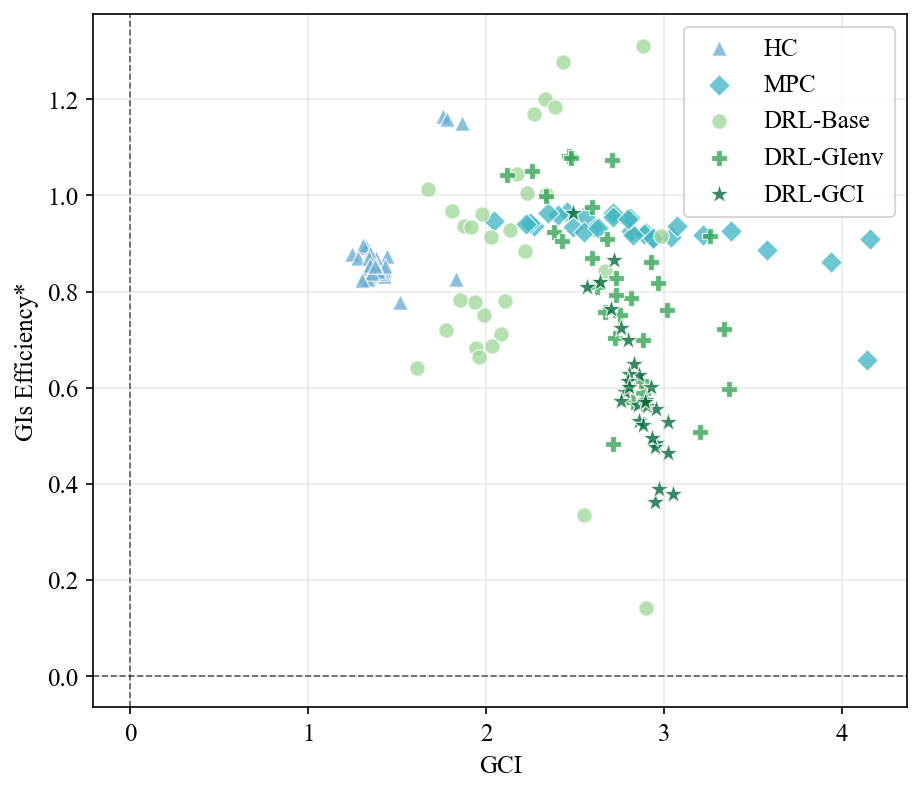

Saved scatter plot to: figures_gci_gi_efficiency_integral_fc\gci_vs_gi_efficiency_integral_fc_scatter.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

for strategy in STRATEGY_ORDER:
    subset = metric_df[metric_df["strategy"] == strategy]
    ax.scatter(
        subset["gci"],
        subset["gi_efficiency"],
        s=95 if strategy == "DRL-GCI" else 55,
        color=STRATEGY_COLORS[strategy],
        marker=STRATEGY_MARKERS[strategy],
        alpha=0.78,
        edgecolors="white",
        linewidths=0.6,
        label=strategy,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
ax.set_xlabel("GCI")
ax.set_ylabel("GIs Efficiency*")
# ax.set_title("Relationship Between GCI and GI Efficiency (Integral FC Numerator)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

scatter_path = FIGURE_DIR / "gci_vs_gi_efficiency_integral_fc_scatter.png"
fig.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved scatter plot to: {scatter_path}")
